In [2]:
# [환경 설정] 한글 폰트 설정 및 필수 라이브러리 로드
# macOS, Windows, Linux, Google Colab 환경에 맞춰 한글 깨짐 없이 동작하도록 자동 감지 설정합니다.

import platform
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np

try:
    import seaborn as sns
except ImportError:
    pass

# 운영체제(OS)별 한글 폰트 자동 설정
system_name = platform.system()
if system_name == 'Darwin':          # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
    plt.rcParams['font.sans-serif'] = ['AppleGothic', 'Apple SD Gothic Neo', 'NanumGothic', 'DejaVu Sans']
elif system_name == 'Windows':       # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['font.sans-serif'] = ['Malgun Gothic', 'NanumGothic', 'DejaVu Sans']
else:                               # Linux / Google Colab
    try:
        nanum_fonts = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]
        if nanum_fonts:
            plt.rcParams['font.family'] = nanum_fonts[0]
        else:
            import subprocess
            subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], check=False, stdout=subprocess.DEVNULL)
            fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
            plt.rcParams['font.family'] = 'NanumGothic'
    except Exception:
        pass
    plt.rcParams['font.sans-serif'] = ['NanumGothic', 'DejaVu Sans']

# 마이너스 기호 깨짐 방지 및 Seaborn 폰트 동기화
plt.rcParams['axes.unicode_minus'] = False
try:
    if 'sns' in locals():
        sns.set_theme(style='whitegrid', font=plt.rcParams['font.family'])
except Exception:
    pass

print(f'✅ 환경 설정 완료! 현재 적용된 폰트: {plt.rcParams["font.family"]}')

✅ 환경 설정 완료! 현재 적용된 폰트: ['AppleGothic']


In [3]:
df = pd.read_csv('21_cmapss_fd001_sample.csv')
print(df.shape)

(1031, 10)


## 실습 1. 변화량으로 급변 탐지하기
원본에서 안 보이던 급변 시점을 변화량으로 찾기

목표
- 직전 대비 변화량으로 원본에서 안 보이던 급변 시점을 찾기

단계
- 2번 엔진 센서의 직전 대비 변화량을 구하기
- 위칸에 원본, 아래칸에 변화량과 0 기준선을 그리기
- 0에서 크게 벗어난 회차를 급변 시점으로 표시

예상 결과
- 변화량 그래프에서 0을 크게 벗어난 몇몇 회차가 급변 후보

(287, 10)


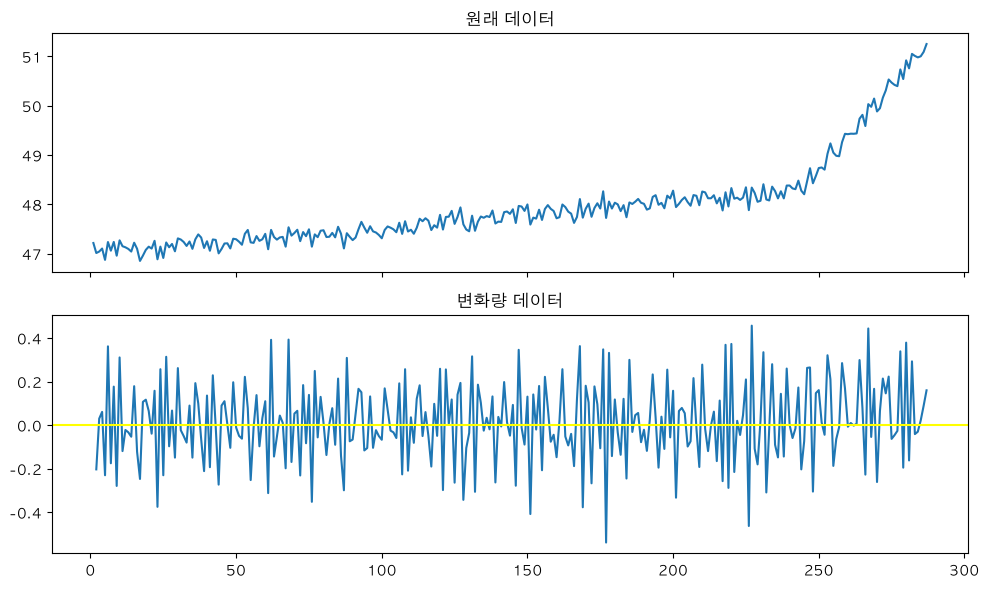

0.54


In [4]:
engine2 = df[df['unit_nr'] == 2]
print(engine2.shape)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

ax1.set_title('원래 데이터')
ax1.plot(engine2['time_cycles'], engine2['s_11'])

ax2.set_title('변화량 데이터')
diff = engine2['s_11'].diff()
ax2.plot(engine2['time_cycles'], diff)

# 0 기준선 긋기
ax2.axhline(0, color='yellow')

plt.tight_layout()
plt.show()

# 최대 급변량 확인
print(round(diff.abs().max(), 2))

## 실습 2. 추세·변동성·변화량 종합 관찰
한 센서를 세 관점으로 한 화면에서 관찰

목표
- 한 센서를 추세·변동성·변화량 세 관점으로 한 화면에서 관찰

단계
- 이동평균으로 추세, 이동표준편차로 변동성, 변화량으로 급변을 각각 구하기
- 세 칸으로 나눠 원본과 추세, 변동성, 변화량을 그리기
- 세 관점을 종합해 센서 상태를 한두 문장으로 정리

예상 결과
- 추세는 완만한 상승, 변동성·변화량은 후반에 커지는 신호

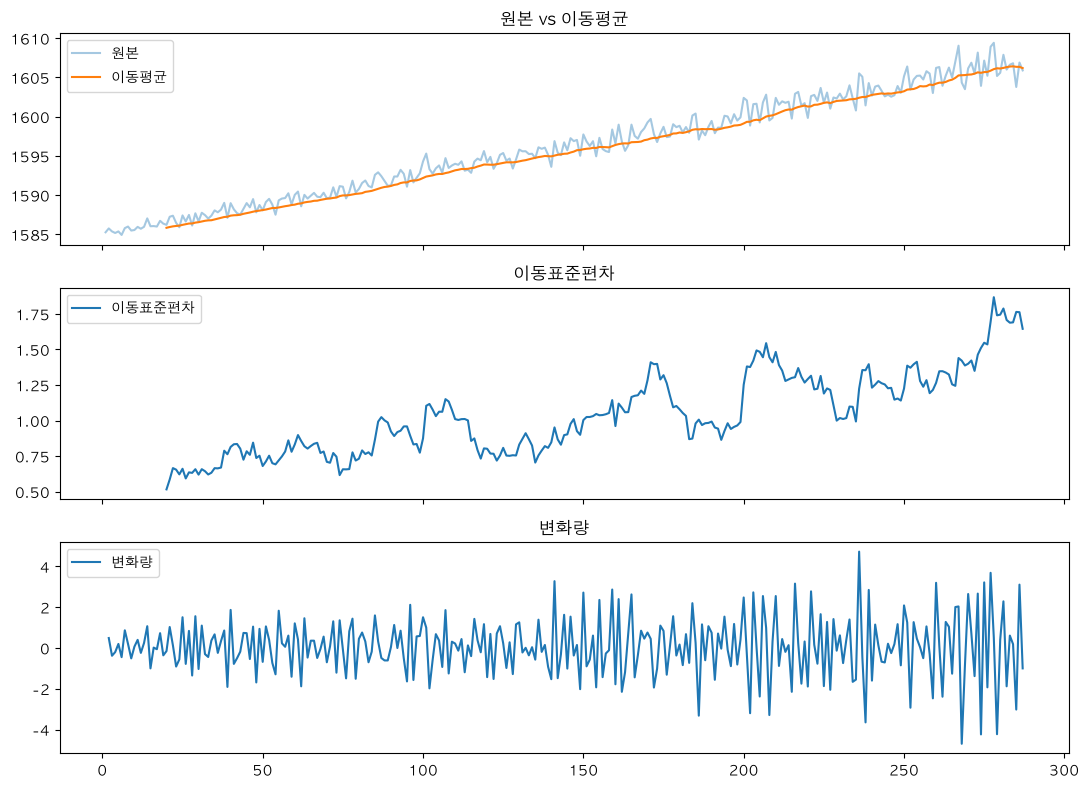

In [5]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(11, 8), sharex=True)

ax1.set_title('원본 vs 이동평균')
ma = engine2['s_3'].rolling(20).mean()
ax1.plot(engine2['time_cycles'], engine2['s_3'], label='원본', alpha=0.4)
ax1.plot(engine2['time_cycles'], ma, label='이동평균')
ax1.legend()

ax2.set_title('이동표준편차')
std = engine2['s_3'].rolling(20).std()
ax2.plot(engine2['time_cycles'], std, label='이동표준편차')
ax2.legend()

ax3.set_title('변화량')
diff = engine2['s_3'].diff()
ax3.plot(engine2['time_cycles'], diff, label='변화량')
ax3.legend()

plt.tight_layout()
plt.show()

## 실습 3. 시간 단위 추세 보기
가로축을 진짜 날짜·시각으로 만들어 추세 보기

목표
- 가로축을 진짜 날짜·시각으로 만들어 원본과 이동평균 추세를 보기

단계
- 시각 글자를 시각 값으로 바꿔 인덱스로 올리기
- 원본을 옅게, 시간 이동평균을 진하게 겹쳐 그리기
- 가로축이 실제 시각인 추세선을 읽기

예상 결과
- 날짜 가로축 위로 매끈하게 상승하는 이동평균선

(192, 6)


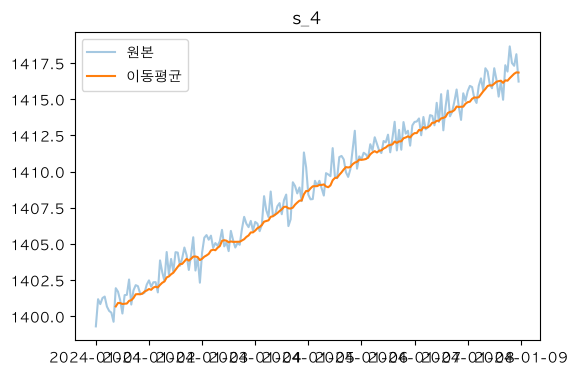

In [6]:
df = pd.read_csv('21_engine1_timestamp_sample.csv')
print(df.shape)

df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.set_index('timestamp').sort_index()

plt.figure(figsize=(6, 4))
plt.title('s_4')
plt.plot(df.index, df['s_4'], label='원본', alpha=0.4)
plt.plot(df.index, df['s_4'].rolling(10).mean(), label='이동평균')
plt.legend()

plt.show()

2026년 8월 28일 수업 시작!

## 실습 3. 시간 단위 추세 보기
가로축을 진짜 날짜·시각으로 만들어 추세 보기

목표
- 가로축을 진짜 날짜·시각으로 만들어 원본과 이동평균 추세를 보기

단계
- 시각 글자를 시각 값으로 바꿔 인덱스로 올리기
- 원본을 옅게, 시간 이동평균을 진하게 겹쳐 그리기
- 가로축이 실제 시각인 추세선을 읽기

예상 결과
- 날짜 가로축 위로 매끈하게 상승하는 이동평균선

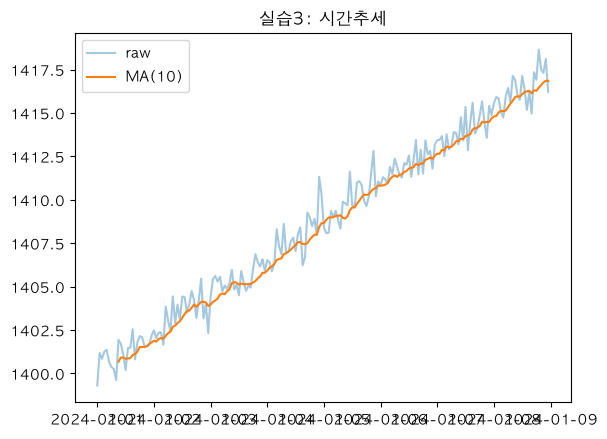

In [ ]:
# [실제 시간 경과에 따른 센서 데이터 추세 스무딩]
# 1. pd.to_datetime()과 set_index(): 문자열 날짜를 인덱스로 변환해 시계열을 셋업합니다.
# 2. plt.plot(ts.index, ...): x축 인덱스에 실제 시간 정보를 매핑하여 가동 흐름을 그립니다.
# * 기계가 매 시간 작동하는 동안 온도가 점진적으로 상승하는 큰 틀의 움직임을
#   10시간 이동평균선(MA(10))을 통해 원본 잡음과 겹쳐 분석함으로써 기저 상승 경향을 파악합니다.
# * x축 데이터로 `ts.index`를 사용할 때 날짜 형식이 깨지는 것을 막기 위해
#   판다스가 matplotlib과 연동하여 자동으로 가독성 있는 축 눈금(날짜 포맷)을 설정해 줍니다.

ts = pd.read_csv('21_engine1_timestamp_sample.csv')
ts['timestamp'] = pd.to_datetime(ts['timestamp'])
ts = ts.set_index('timestamp')

plt.plot(ts.index, ts['s_4'], alpha=0.4, label='raw')
plt.plot(ts.index, ts['s_4'].rolling(10).mean(), label='MA(10)')
plt.title('실습3: 시간추세')
plt.legend()
plt.show()

## 실습 4. 시간 단위 집계로 주기 패턴 보기
원본·6시간·하루 평균을 겹쳐 리샘플링 효과 확인

목표
- 원본·6시간·하루 평균을 겹쳐 리샘플링이 큰 패턴을 드러냄을 확인

단계
- 시각 인덱스 데이터에서 6시간·하루 단위 평균을 각각 구하기
- 원본과 두 집계를 한 그래프에 겹쳐 그리기
- 단위가 커질수록 잔잔해지며 큰 흐름이 드러남을 확인

예상 결과
- 하루 평균은 8개 점으로, 원본의 잔떨림이 사라진 매끈한 흐름

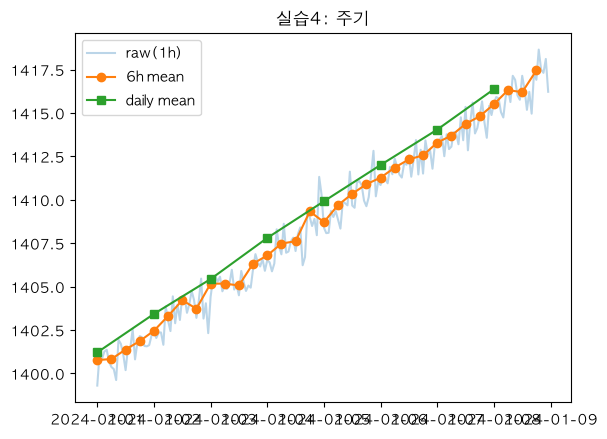

하루 평균 개수: 8


In [ ]:
# [다운샘플링 주기에 따른 시계열의 주기적(Periodicity) 변동 관찰]
# 1. resample('6h').mean(): 6시간 단위로 축약하여 교대 근무 단위의 변동 패턴을 요약합니다.
# 2. resample('D').mean(): 하루('D', Day) 단위의 데이터를 요약하여 일별 등락만을 강조합니다.
# * 1시간 단위 신호에서 주기적으로 반복되는 일일 부하 변동(예: 낮에 운전이 많고 밤에 적어 온도가 오르내림)을
#   6시간 및 하루 평균선으로 축약하여 노이즈를 필터링하고 장기 운전 주기를 검증합니다.
# * `marker='o'`, `marker='s'` 등 마커 속성을 부여해 선 위에 샘플링 시점(점, 사각형)을 명시적으로 찍으면,
#   데이터 해상도가 얼만큼 거칠어졌는지 시각적으로 쉽게 비교할 수 있습니다.

h6 = ts['s_4'].resample('6h').mean()
day = ts['s_4'].resample('D').mean()

plt.plot(ts.index, ts['s_4'], alpha=0.3, label='raw(1h)')
plt.plot(h6.index, h6, marker='o', label='6h mean')
plt.plot(day.index, day, marker='s', label='daily mean')
plt.legend()
plt.title('실습4: 주기')
plt.show()

print('하루 평균 개수:', len(day))

## 실습 5. 누락 시점 보간 후 재분석
채우는 방법에 따라 결과가 어떻게 다른지 비교

목표
- 누락을 만들고 채우는 방법에 따라 결과가 어떻게 다른지 비교

단계
- 작은 예시에서 앞값 채움과 선형 보간의 결과 차이를 비교
- 시각 데이터 일부를 일부러 비우고 누락 개수를 확인
- 보간으로 채운 뒤 누락이 사라졌는지 확인

예상 결과
- 앞값 채움은 계단 모양, 선형 보간은 12·14로 이어짐; 보간 후 0

In [ ]:
# [결측치 보정 기법 — 직전값 대체(ffill) vs 선형보간(interpolate)]
# 1. ffill() (Forward Fill): 가장 최근에 정상 측정된 앞의 값을 그대로 끌어다 결측 구간에 덮어씁니다.
# 2. interpolate() (Linear Interpolation): 결측 구간의 이전 정상값과 이후 정상값 사이를 일정한 경사로 이어 채웁니다.
# 3. s2.iloc[50:55] = np.nan: 의도적으로 5개 행에 결측을 주입한 후 interpolate를 통해 복원 테스트를 진행합니다.
# * 통신 장비 오류나 센서 재부팅으로 인해 누락된 구간이 존재하면 분석 함수(특히 시계열 분해나 머신러닝)가
#   작동하지 않고 에러를 내므로, 시간적 흐름에 부합하도록 주변 수치를 추정하여 견고하게 결측을 제거해야 합니다.
# * ffill()과 interpolate() 모두 복원 결과를 기존 시리즈나 데이터프레임에 재할당해주거나
#   `inplace=True` 파라미터를 넘겨주어야 원본이 수정됩니다.

s = pd.Series([10.0, np.nan, np.nan, 16.0, 18.0])
print('ffill:', s.ffill().tolist())
print('interpolate:', s.interpolate().tolist())

s2 = ts['s_4'].copy(); s2.iloc[50:55] = np.nan
print('누락 개수:', int(s2.isna().sum()))
print('보간 후:', int(s2.interpolate().isna().sum()))

ffill: [10.0, 10.0, 10.0, 16.0, 18.0]
interpolate: [10.0, 12.0, 14.0, 16.0, 18.0]
누락 개수: 5
보간 후: 0


## 실습 6. 시계열 분해 시연·관찰
원본·추세·주기·나머지 네 부분으로 분해해 관찰

목표
- 시계열을 원본·추세·주기·나머지 네 부분으로 분해해 관찰(강사 시연)

단계
- 분해 도구로 시각 데이터를 더하기 모형으로 분해
- 원본·추세·계절·잔차 네 칸을 함께 보기
- 추세 칸이 이동평균 추세와 비슷한지 비교

예상 결과
- 네 칸으로 나뉜 분해 결과 — 추세는 상승, 주기는 반복 무늬

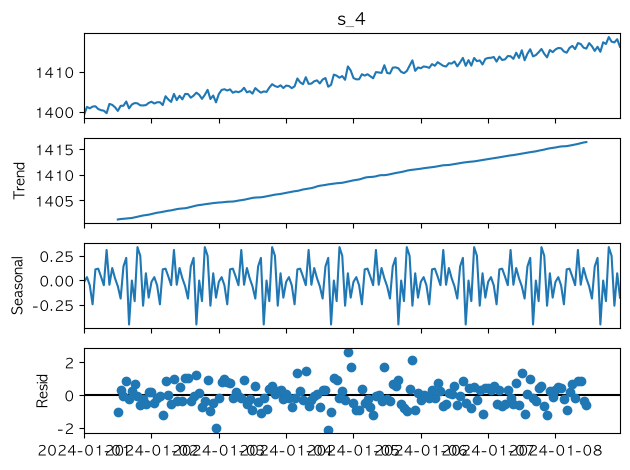

In [ ]:
# [시계열 분해(Seasonal Decomposition)를 통한 시계열 구성 성분 추출]
# 1. seasonal_decompose: 신호를 장기 추세(Trend), 반복 주기(Seasonal), 그리고 무작위 잡음(Residual)의 합(additive)으로 분해합니다.
# 2. period=24: 매시 수집된 데이터에서 하루 주기(24시간)의 계절성이 반복된다고 명시적으로 정의합니다.
# * 센서 데이터에 복합적으로 꼬여있는 노이즈(Residual)와 근무 교대 주기(Seasonal)를 각각 분리하고,
#   오로지 기계의 노화 속도를 대변하는 순수 장기 신호(Trend)만 필터링하여 남기기 위한 통계적 전처리 기술입니다.
# * statsmodels의 seasonal_decompose는 데이터 내에 NaN(결측치)이 포함되어 있으면 실행 도중 에러를 유발하므로,
#   반드시 `interpolate()` 등으로 결측치를 완전 보정한 정제 상태에서 호출해야 합니다.

from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(ts['s_4'], model='additive', period=24)
result.plot()
plt.tight_layout()
plt.show()